In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

In [11]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28,28,1)
x_test = x_test.reshape(-1, 28,28,1)



In [14]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
from IPython.core import history
cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = cnn_model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.9734 - loss: 0.0869 - val_accuracy: 0.9861 - val_loss: 0.0427
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9861 - loss: 0.0453 - val_accuracy: 0.9881 - val_loss: 0.0349
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.9901 - loss: 0.0325 - val_accuracy: 0.9902 - val_loss: 0.0306
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9919 - loss: 0.0241 - val_accuracy: 0.9888 - val_loss: 0.0324
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9938 - loss: 0.0189 - val_accuracy: 0.9919 - val_loss: 0.0249


In [21]:
test_loss, test_acc = cnn_model.evaluate(x_test, y_test, verbose=2)
print(test_acc)

313/313 - 2s - 7ms/step - accuracy: 0.9919 - loss: 0.0249
0.9919000267982483


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


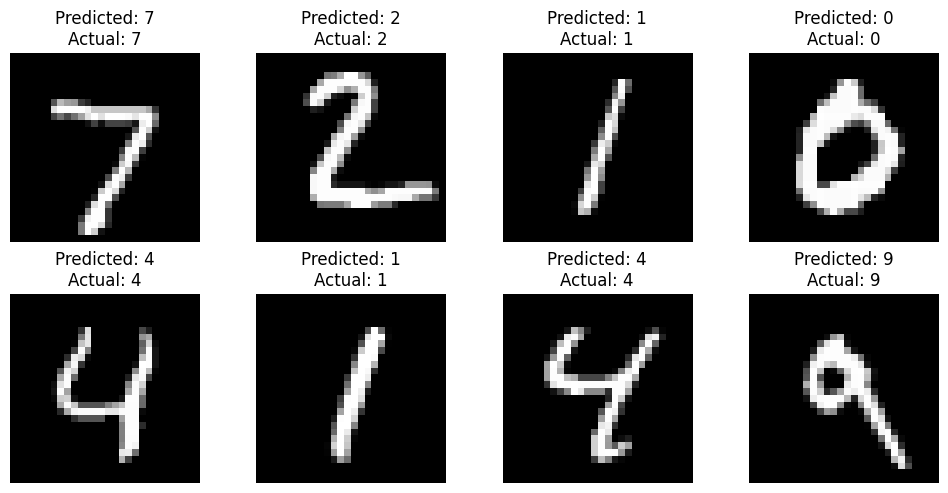

In [22]:
y_pred = cnn_model.predict(x_test[:8])
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
  ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
  ax.set_title(f"Predicted: {np.argmax(y_pred[i])}\nActual: {y_test[i]}")
  ax.axis('off')
plt.tight_layout()
plt.show()